In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "dllm").exists():
    repo_root = repo_root.parent
if (repo_root / "dllm").exists():
    sys.path.insert(0, str(repo_root))

import numpy as np
import torch
from datasets import load_dataset
import os
import shutil
from matplotlib import patches, gridspec
import matplotlib.pyplot as plt

from dllm.DLLMExpr import BaselineConfig, DLLMExpr
from dllm.utils import decode_outputs
from visualization.utils.utils import visualize_overall_steps, visualize_single_step
from visualization.visualize_gen import run_gen_until

%matplotlib inline  
# 当引入外部文件发生变化时(如.py)自动刷新缓存，无需重启kernel
%load_ext autoreload
%autoreload 2

In [2]:
# 加载Model
device = 'cuda:0'

gsm8k_dataset = load_dataset('openai/gsm8k', 'main')
gsm8k_prompts = gsm8k_dataset['test']['question'][2:3]
model_path = "/home/xiangzhong_ayl/dllm/works/dllm-research/models/LLaDA-8B-Instruct"
token_info = {
    'mask_id': 126336,
    'bos_id': 126080,
    'pad_id': 126081,
    'eos_id': 126081,
    'eot_id': 126348
}
config = BaselineConfig(
    cfg_scale=0.0,
    temperature=0.0,
    positional_weights_type='none',
    remasking="low_confidence",
    decoding_method="fixed",
    factor=1,
    k=1,
    confidence_threshold=0.9,
    **token_info
)
sampler = DLLMExpr.from_path(
    model_path=model_path,
    device=device,
    config=config,
    torch_dtype=torch.bfloat16
)
tokenizer = sampler.tokenizer

# 加载tuned_lens
from tool.tuned_lens.tuned_lens import TunedLens

tuned_lens = TunedLens.from_model_and_pretrained_lens(
    model=sampler.model,
    lens_path=f'{repo_root}/tool/tuned_lens/checkpoints/model.safetensors',
    device=device
)
tuned_lens.eval()

Loading model and tokenizer from path: /home/xiangzhong_ayl/dllm/works/dllm-research/models/LLaDA-8B-Instruct, dllm_type: llada


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

cfg_scale: 0.0
temperature: 0.0
mask_id: 126336
bos_id: 126080
pad_id: 126081
eos_id: 126081
eot_id: 126348
max_gen_length: 2048
max_steps: 2048
positional_weights_type: none
max_weight: 1.0
initial_min_weight: 0.05
ur_factor: 1.0
dllm_type: llada
remasking: low_confidence
decoding_method: fixed
k: 1
factor: 1
confidence_threshold: 0.9


TunedLens(
  (base_model): LLaDAModelLM(
    (model): LLaDAModel(
      (transformer): ModuleDict(
        (wte): Embedding(126464, 4096)
        (emb_drop): Dropout(p=0.0, inplace=False)
        (ln_f): RMSLayerNorm()
        (blocks): ModuleList(
          (0-31): 32 x LLaDALlamaBlock(
            (dropout): Dropout(p=0.0, inplace=False)
            (act): SiLU()
            (attn_out): Linear(in_features=4096, out_features=4096, bias=False)
            (ff_out): Linear(in_features=12288, out_features=4096, bias=False)
            (rotary_emb): RotaryEmbedding()
            (attn_norm): RMSLayerNorm()
            (ff_norm): RMSLayerNorm()
            (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
            (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
            (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
            (ff_proj): Linear(in_features=4096, out_features=12288, bias=False)
            (up_proj): Linear(in_feat

In [3]:
from datasets import load_dataset
from dllm.DLLM import GenerateOutput

sampler.model.to(device)

block_length = 32
gen_length = 284

qid = 5
gsm8k_dataset = load_dataset('openai/gsm8k', 'main')
prompt_text = gsm8k_dataset['test']['question'][qid]
prompt_text += "\nWrap the final answer in a \\boxed{}." 

m = [{"role": "user", "content": prompt_text}, ]
prompt = tokenizer.apply_chat_template(m, add_generation_prompt=True, tokenize=False)
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

prompt_len = input_ids.shape[1]
OUT: GenerateOutput = sampler.generate(prompt=input_ids, gen_length=gen_length, max_steps=gen_length, block_length=block_length, records=['metrics', 'state_trace'])
metrics = OUT.metrics
outputs = OUT.state_trace['outputs_all'] # (T, Seq)
confidences = OUT.state_trace['confidences_all']
transfer_idxs = OUT.state_trace['transfer_idxs_all']
attentions = OUT.state_trace['attentions_all']
hidden_states = OUT.state_trace['hidden_states_all']
answer = tokenizer.batch_decode(OUT.out[:, prompt_len:], skip_special_tokens=True)[0]
outputs_decoded = decode_outputs(outputs, tokenizer)

print(f"metrics={metrics}")
outputs.shape, confidences.shape, transfer_idxs.shape, attentions.shape

decoding method: fixed, k=1, factor=1, confidence_threshold=0.9.
adjusted gen_length: 284, n_blocks: 9.
metrics=GenerationMetrics(use_seconds=39.02915197699622, use_steps=130, n_gen_tokens=284, tokens_per_second=7.276612112079443, step_reduction_ratio=2.1846153846153844)


((130, 364), (130, 364), (130, 364), (130, 32, 32, 364, 364))

Compute Attn Sink

In [4]:
from tool.attn_sink import sink_metric_epsilon
sink_metrics = sink_metric_epsilon(attentions, epsilon=3)
sink_head_avg = sink_metrics['sink_mask_head_avg'].numpy()  # (T, L, S)
sink_layer_head_avg = sink_metrics['sink_mask_layer_head_avg'].numpy()  # (T, S)
sink_head_avg.shape, sink_layer_head_avg.shape

((130, 32, 364), (130, 364))

Plot Settings

In [5]:
output_dirname = f"{repo_root}/visualization/huashan2/imgs/decodings/gsm8k_qid_{qid}_GL{gen_length}BL{block_length}"
os.makedirs(output_dirname, exist_ok=True)

Plot Decoding across all steps

In [ ]:
# steps输出结果整体 可视化
output_filename = f"{output_dirname}/gsm8k_qid_{qid}_GL{gen_length}BL{block_length}.pdf"
visualize_overall_steps(
    outputs_decoded, confidences, transfer_idxs, sink_mask=sink_layer_head_avg,
    prompt=prompt, answer=answer, 
    is_show=False, is_save=True, output_filename=output_filename,
    color_map='Blues'
)
# undecoded outputsdecoded
# visualize_overall_steps(
#     outputs, confidences, transfer_idxs, sink_mask=sink_mask,
#     prompt=prompt, answer=answer, 
#     is_show=False, is_save=True, output_filename=output_filename
# )

Plot hidden EOS confidence across steps 

In [ ]:
temp_device = device  # 可以换个设备以防止显存溢出
hidden_states_steps = torch.tensor(hidden_states[:, -1, :, :]).type(torch.bfloat16)   # (T, S, H)
T, S, H = hidden_states_steps.shape
probs_steps = []
sz = 8 # 8个step一次unembedding，防止缓存溢出
unembedding_matrix = sampler.model.get_output_embeddings().to(temp_device) 
for t in range(0, T, sz):
    hidden_states_batch = hidden_states_steps[t: t+sz].to(temp_device)
    unembeded_batch = unembedding_matrix(hidden_states_batch).softmax(dim=-1)
    probs_steps.append(unembeded_batch.type(torch.float32).to('cpu'))  # (sz, S, V)
probs_steps = torch.cat(probs_steps, dim=0)  # (T, S, V)

# 避免占别人的多卡
import gc
del unembedding_matrix
del hidden_states_steps
gc.collect()
torch.cuda.empty_cache()
eos_id = 126081
eos_probs_steps = probs_steps[:, :, eos_id]  # (T, S)

In [ ]:
# struinfo_output_dirname = f"{output_dirname}/structural_token_probs"
# os.makedirs(struinfo_output_dirname, exist_ok=True)
# 横坐标seq_len，纵坐标steps, 颜色为eos概率
plt.figure(figsize=(S * 0.5, T * 0.5))
plt.imshow(eos_probs_steps, aspect='auto', cmap='Blues', vmin=0, vmax=1, rasterized=False)
plt.colorbar(label='EOS Probability')

plt.xticks(np.arange(0, S, 32))
plt.yticks(np.arange(0, T, 32))
plt.xlabel('positions')
plt.ylabel('steps')
ax = plt.gca()
ax.set_xticklabels(np.arange(0, S, 32)) 
ax.set_yticklabels(np.arange(0, T, 32)) 
plt.title(f'EOS Probability Heatmap Gen_length={gen_length} Block_length={block_length}')


# 在prompt_len位置绘制虚线
if prompt_len > 0:
    plt.axvline(x=prompt_len - 0.5, color='red', linestyle='--', linewidth=1.5, alpha=1)
# ax.axis('off')
col_off = 1

plt.tight_layout()
plt.savefig(f'{output_dirname}/eos_probs.pdf')
plt.show()

plot decoding for each step

In [16]:
lens_type = 'tuned_lens'
# shape: (T, n_layers + 1, seq_len, hidden_size)，0是embedding层输入，1~n_layers是每层输出的hidden states
# hidden_states_all = np.load(f'{repo_root}/visualization/huashan2/data/hidden_states_gsm8k_qid_0_L192.npy')
hidden_states_all = OUT.state_trace['hidden_states_all']   
T, n_layers, seq_len, hs = hidden_states_all.shape
n_layers -= 1  # 修正n_layers, 不考虑最后一个hidden states(hf返回的是经layer_norm的)

# (T, n_layers, seq_len) 
decoded_tokens_all = []
pred_confidences_all = []
eos_probs_steps_layers = []   # 专门记录eos probs，无论它是否为top-1 token

for step_idx in range(T):
    # np读取rawdata/hidden_states_gsm8k_pmt0.npy文件
    hidden_states_step_ts = torch.tensor(hidden_states_all[step_idx])  # shape: (n_layers, seq_len, hidden_size)
    decoded_tokens_step = []
    pred_confidences_step = []
    eos_probs_step = []

    with torch.no_grad():
        # 最后一层一定直接logit lens即可不需要tuned lens
        for layer_idx in range(0, n_layers):
            # 注意：Tuned Lens forward 需要 [Batch, Seq, Dim]
            h = hidden_states_step_ts[layer_idx].unsqueeze(0).type(sampler.model.dtype).to(device)  # [1, Seq, Hidden]
            if lens_type == 'tuned_lens' and layer_idx < n_layers - 1:
                mid_logits = tuned_lens.forward(h, layer_idx)  # [1, Seq, Vocab]. layer_idx=0是embedding层输入的hidden states所以要layer_idx - 1
            else:
                mid_logits = tuned_lens.unembed(h)  # logit lens
            
            probs = torch.softmax(mid_logits, dim=-1)   # (1, Seq, Vocab)

            # 正常收集每层的top-1 probs
            max_probs, max_ids = torch.max(probs, dim=-1)  # (1, Seq)
            
            layer_decoded = []
            for pos in range(seq_len):
                token_text = tokenizer.decode(max_ids[0, pos])
                layer_decoded.append(token_text)
            decoded_tokens_step.append(layer_decoded)
            pred_confidences_step.append(max_probs[0].cpu().type(torch.float32).numpy())

            # 额外收集eos token probs
            eos_probs = probs[:, :, eos_id]  # (1, Seq)
            eos_probs_step.append(eos_probs[0].cpu().type(torch.float32).numpy())

    # 最后一层append上step级的decoded output和confidence
    x0_decoded = []
    for pos in range(seq_len):
        token_text = tokenizer.decode(outputs[step_idx, pos])
        x0_decoded.append(token_text)
    decoded_tokens_step.append(x0_decoded)
    pred_confidences_step.append(confidences[step_idx])
    eos_probs_step.append(eos_probs_steps[step_idx])    # 收集eos probs  
        
    decoded_tokens_all.append(decoded_tokens_step)
    pred_confidences_all.append(pred_confidences_step)
    eos_probs_steps_layers.append(eos_probs_step)   # 收集eos probs
    
# decoded_tokens_all = np.array(decoded_tokens_all)  # shape: (T, n_layers, seq_len)
pred_confidences_all = np.array(pred_confidences_all)  # shape: (T, n_layers, seq_len)
eos_probs_steps_layers = np.array(eos_probs_steps_layers)  # shape: (T, n_layers, seq_len)

len(decoded_tokens_all), pred_confidences_all.shape, eos_probs_steps_layers.shape

(54, (54, 33, 180), (54, 33, 180))

tuned_lens eos token

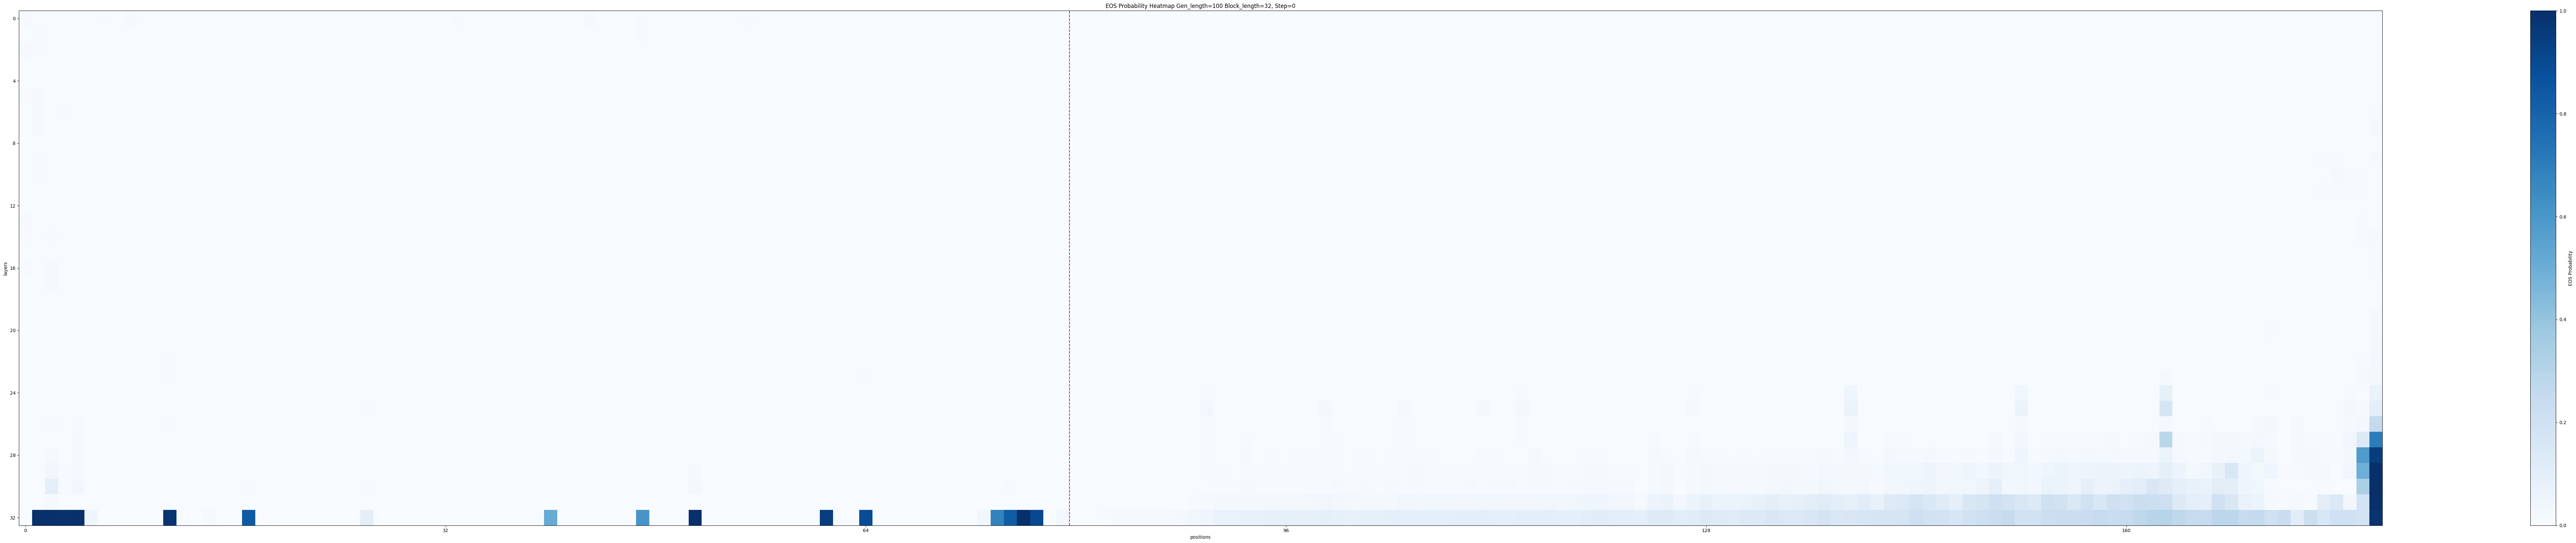

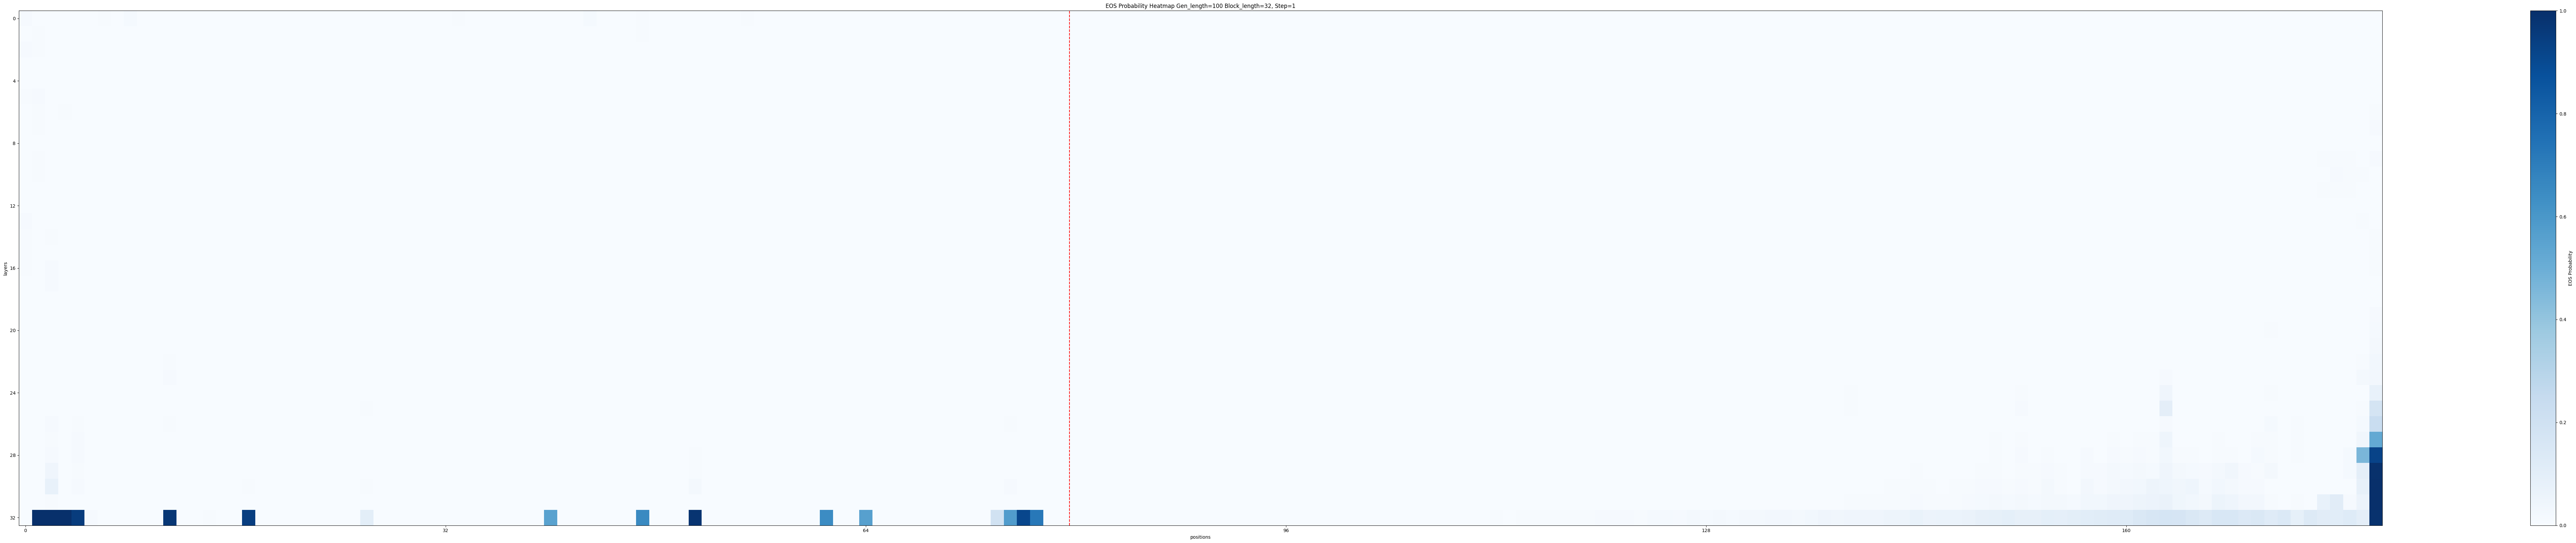

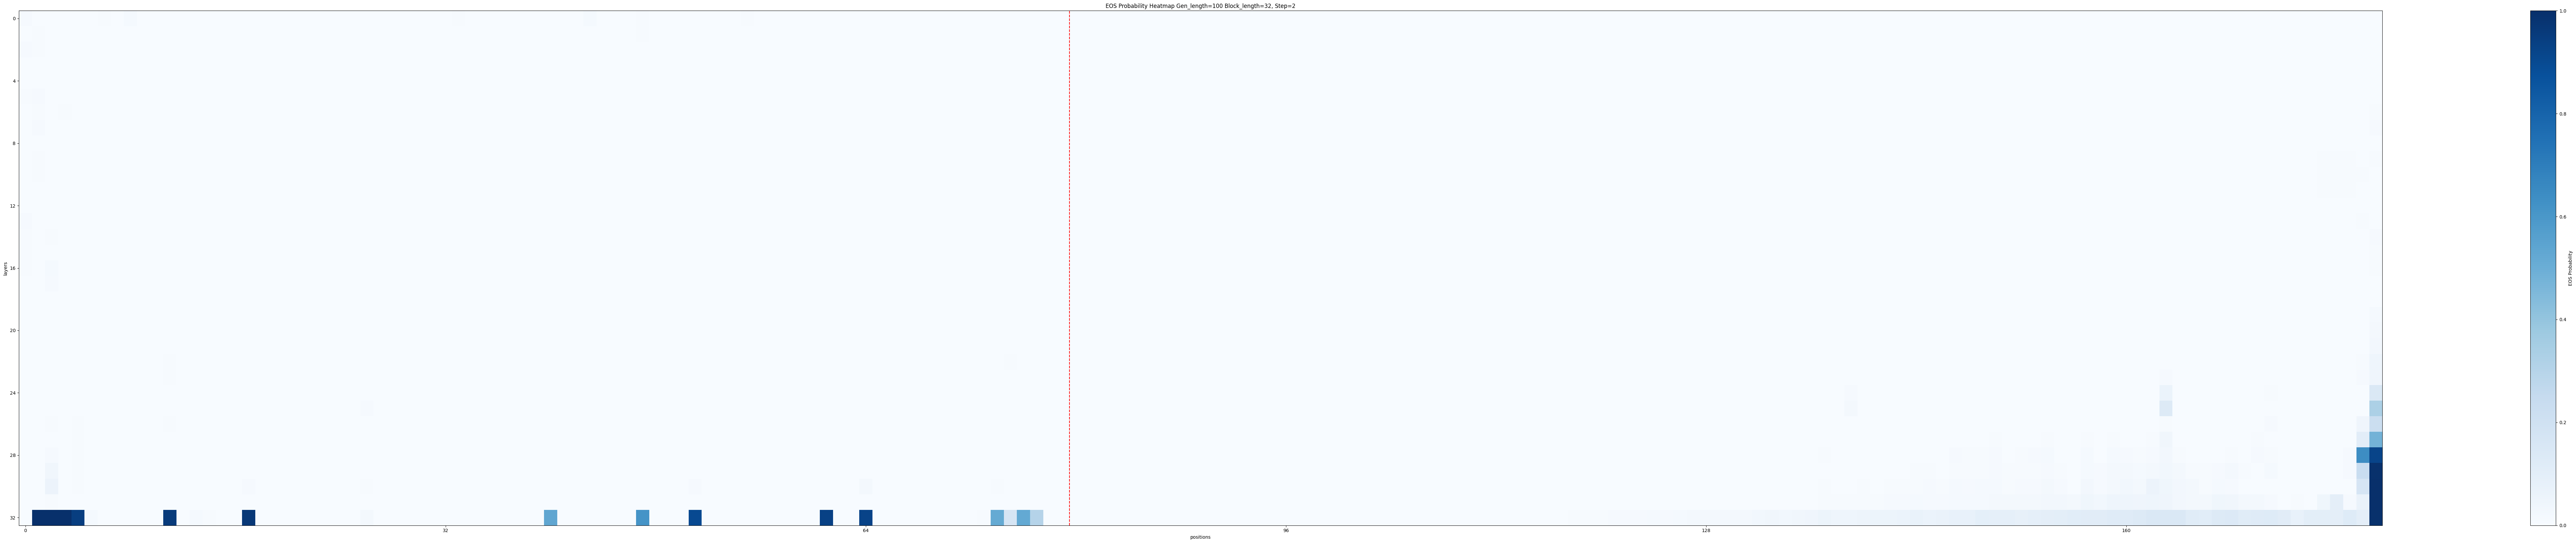

In [17]:
# struinfo_output_dirname = f"{output_dirname}/structural_token_probs"
# os.makedirs(struinfo_output_dirname, exist_ok=True)
eos_id = 126081
T, L, S = eos_probs_steps_layers.shape
step_idxs = [0, 1, 2]
for i, step_idx in enumerate(step_idxs):
    # 横坐标seq_len，纵坐标steps, 颜色为eos概率
    plt.figure(figsize=(S * 0.5, L * 0.5))
    plt.imshow(eos_probs_steps_layers[step_idx], aspect='auto', cmap='Blues', vmin=0, vmax=1, rasterized=False)
    plt.colorbar(label='EOS Probability')

    plt.xticks(np.arange(0, S, 32))
    plt.yticks(np.arange(0, L, 4))
    plt.xlabel('positions')
    plt.ylabel('layers')
    plt.title(f'EOS Probability Heatmap Gen_length={gen_length} Block_length={block_length}, Step={step_idx}')

    # 在prompt_len位置绘制虚线
    if prompt_len > 0:
        plt.axvline(x=prompt_len - 0.5, color='red', linestyle='--', linewidth=1.5, alpha=1)
    # ax.axis('off')
    col_off = 1

    plt.tight_layout()
    plt.savefig(f'{output_dirname}/tunedlens_eos_probs_step{step_idx}.pdf')
    plt.show()
    # if i != 0:
    #     plt.close()

tuned_lens top-1 tokens

In [ ]:
# 为embedding层添加一个全0的sink mask
embedding_layer_pad = np.expand_dims(np.zeros_like(sink_head_avg[:, 0]), axis=1)  # (T, 1, S)
sink_mask_layers = np.concatenate([embedding_layer_pad, sink_head_avg], axis=1)

# 各steps的tuned_lens 可视化
# output_dirname = f"{repo_root}/visualization/huashan2/imgs/decodings/gsm8k_qid_{qid}_GL{gen_length}BL{block_length}"
# os.makedirs(output_dirname, exist_ok=True)
step_idxs = [32, 33, 34, 35]
for step_idx in step_idxs:
    output_filename = f"{output_dirname}/gsm8k_qid_{qid}_GL{gen_length}BL{block_length}_step_{step_idx}.pdf"
    visualize_single_step(
        step_idx=step_idx, 
        layer_outputs=decoded_tokens_all[step_idx], layer_confidences=pred_confidences_all[step_idx],
        sink_mask=sink_mask_layers[step_idx], transfer_idxs=transfer_idxs[step_idx],
        prompt=prompt, answer=answer, 
        is_show=False, is_save=True, output_filename=output_filename
    )

Save DPI: 50
